# Cross-Sectional Reversal Backtest

This notebook evaluates the economic performance of the cross-sectional reversal signals identified during signal research.

At each hour:

- the bottom three cryptocurrencies are held long;
- the top three cryptocurrencies are held short;
- positions are equally weighted within each side;
- the portfolio is rebalanced hourly.

Gross and net performance are compared after accounting for turnover-based transaction costs.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
processed_data_dir = Path("data/processed")

data_path = (
    processed_data_dir
    / "crypto_10_assets_1h_clean.parquet"
)

df = pd.read_parquet(data_path)

df = (
    df
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

df.head()

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,symbol
0,2023-01-01 00:00:00+00:00,0.2458,0.2459,0.2441,0.2445,4476440.1,1.096436e+06,1979,2325058.2,569457.21279,ADAUSDT
1,2023-01-01 01:00:00+00:00,0.2446,0.2455,0.2443,0.2452,2247531.8,5.498366e+05,1110,1176230.7,287778.97095,ADAUSDT
2,2023-01-01 02:00:00+00:00,0.2452,0.2462,0.2449,0.2456,1878723.3,4.616204e+05,923,993206.7,243976.96105,ADAUSDT
3,2023-01-01 03:00:00+00:00,0.2456,0.2458,0.2452,0.2454,2778149.2,6.818411e+05,1139,1332950.4,327156.00797,ADAUSDT
4,2023-01-01 04:00:00+00:00,0.2454,0.2455,0.2444,0.2446,1326482.4,3.247254e+05,807,574781.7,140711.28901,ADAUSDT


In [ ]:
# step 1 calculate the return

In [6]:
df["return_1h"] = (
    df.groupby("symbol")["close"]
    .pct_change()
)

df["future_return_1h"] = (
    df.groupby("symbol")["return_1h"]
    .shift(-1)
)

In [ ]:
# test two horizon

In [8]:
backtest_horizons = [
    1,
    3,
]

for horizon in backtest_horizons:

    df[f"signal_{horizon}h"] = (
        df.groupby("symbol")["close"]
        .pct_change(periods=horizon)
    )

    df[f"rank_{horizon}h"] = (
        df.groupby("open_time")[f"signal_{horizon}h"]
        .rank(
            method="first",
            ascending=True,
        )
    )

In [ ]:
# step 2:For the reversal strategy: 

## Portfolio Construction -- reversal strategy

For the reversal strategy:

- ranks 1–3： long;
- ranks 8–10： short;
- ranks 4-7: do nothing
- each long position receives a weight of \(+1/3\);
- each short position receives a weight of \(-1/3\).

The portfolio therefore has gross exposure of 200% and net exposure of 0%.

In [11]:
df["weight_1h"] = 0.0

df.loc[
    df["rank_1h"] <= 3,
    "weight_1h",
] = 1 / 3

df.loc[
    df["rank_1h"] >= 8,
    "weight_1h",
] = -1 / 3

In [ ]:
# step 3: backtesting

In [13]:
sample_time = pd.Timestamp(
    "2023-01-02 00:00:00",
    tz="UTC",
)

df.loc[
    df["open_time"] == sample_time,
    [
        "symbol",
        "signal_1h",
        "rank_1h",
        "weight_1h",
        "future_return_1h",
    ],
].sort_values("rank_1h")

,symbol,signal_1h,rank_1h,weight_1h,future_return_1h
210448,SOLUSDT,-0.008008,1.0,0.333333,-0.006054
184145,LTCUSDT,-0.007192,2.0,0.333333,-0.003693
236751,XRPUSDT,-0.006200,3.0,0.333333,-0.033571
105236,DOGEUSDT,-0.005979,4.0,0.000000,-0.009166
26327,AVAXUSDT,-0.005520,5.0,0.000000,-0.006475
24,ADAUSDT,-0.004402,6.0,0.000000,-0.004823
157842,LINKUSDT,-0.003909,7.0,0.000000,-0.007670
52630,BNBUSDT,-0.003273,8.0,-0.333333,-0.006158
131539,ETHUSDT,-0.001816,9.0,-0.333333,-0.002504
78933,BTCUSDT,-0.001709,10.0,-0.333333,-0.001405


In [15]:
df.groupby("open_time")["weight_1h"].agg(
    net_exposure="sum",
    gross_exposure=lambda x: x.abs().sum(),
).dropna().head()

,net_exposure,gross_exposure
open_time,,
2023-01-01 00:00:00+00:00,0.0,0.0
2023-01-01 01:00:00+00:00,0.0,2.0
2023-01-01 02:00:00+00:00,0.0,2.0
2023-01-01 03:00:00+00:00,0.0,2.0
2023-01-01 04:00:00+00:00,0.0,2.0


In [ ]:
# step 4: caculate hourly return

In [17]:
df["weighted_return_1h"] = (
    df["weight_1h"]
    * df["future_return_1h"]
)

In [23]:
portfolio_1h = (
    df.groupby("open_time")["weighted_return_1h"]
    .sum(min_count=1)
    .rename("gross_return")
    .to_frame()
    .dropna()
)

## Gross Portfolio Returns

The reversal portfolio holds the bottom three cryptocurrencies long and the top three cryptocurrencies short, with equal weights on each side.

The portfolio has zero net exposure and 200% gross exposure. Each hourly gross return is calculated by multiplying the position weight of each cryptocurrency by its subsequent one-hour return and summing across all assets.

The initial observations show that portfolio returns can be volatile. These individual hours do not determine overall strategy performance, which must be evaluated across the full sample and after transaction costs.

In [ ]:
# step 5: calculate hourly turnover

In [29]:


weights_wide = df.pivot(
    index="open_time",
    columns="symbol",
    values="weight_1h",
).fillna(0).sort_index()

weights_wide.head()

symbol,ADAUSDT,AVAXUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LINKUSDT,LTCUSDT,SOLUSDT,XRPUSDT
open_time,,,,,,,,,,
2023-01-01 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-01-01 01:00:00+00:00,0.000000,0.333333,0.333333,0.000000,0.000000,0.000000,-0.333333,-0.333333,-0.333333,0.333333
2023-01-01 02:00:00+00:00,-0.333333,0.000000,0.333333,-0.333333,0.000000,0.000000,0.000000,-0.333333,0.333333,0.333333
2023-01-01 03:00:00+00:00,0.000000,0.333333,0.000000,0.000000,-0.333333,0.000000,-0.333333,0.333333,0.333333,-0.333333
2023-01-01 04:00:00+00:00,0.000000,0.333333,0.000000,-0.333333,0.333333,-0.333333,0.000000,-0.333333,0.333333,0.000000


In [31]:
weight_changes = (
    weights_wide
    .diff()
    .fillna(0)
)

hourly_turnover = (
    weight_changes
    .abs()
    .sum(axis=1)
    .rename("turnover")
)

hourly_turnover.head()

open_time
2023-01-01 00:00:00+00:00    0.000000
2023-01-01 01:00:00+00:00    2.000000
2023-01-01 02:00:00+00:00    2.000000
2023-01-01 03:00:00+00:00    3.333333
2023-01-01 04:00:00+00:00    2.666667
Name: turnover, dtype: float64

In [ ]:
# step 6 join the turnover

In [33]:
portfolio_1h = portfolio_1h.join(
    hourly_turnover,
    how="left",
)

portfolio_1h.head()

,gross_return,turnover
open_time,,
2023-01-01 00:00:00+00:00,0.000000,0.000000
2023-01-01 01:00:00+00:00,-0.000494,2.000000
2023-01-01 02:00:00+00:00,-0.000605,2.000000
2023-01-01 03:00:00+00:00,-0.000759,3.333333
2023-01-01 04:00:00+00:00,-0.001434,2.666667


In [ ]:
# Step 7: apply turnover-based transaction costs

In [35]:


transaction_cost_rate = 0.002

portfolio_1h["transaction_cost"] = (
    portfolio_1h["turnover"]
    * transaction_cost_rate
)

portfolio_1h["net_return"] = (
    portfolio_1h["gross_return"]
    - portfolio_1h["transaction_cost"]
)

portfolio_1h.head(10)

,gross_return,turnover,transaction_cost,net_return
open_time,,,,
2023-01-01 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000
2023-01-01 01:00:00+00:00,-0.000494,2.000000,0.004000,-0.004494
2023-01-01 02:00:00+00:00,-0.000605,2.000000,0.004000,-0.004605
2023-01-01 03:00:00+00:00,-0.000759,3.333333,0.006667,-0.007426
2023-01-01 04:00:00+00:00,-0.001434,2.666667,0.005333,-0.006767
2023-01-01 05:00:00+00:00,0.000013,3.333333,0.006667,-0.006653
2023-01-01 06:00:00+00:00,0.002914,2.666667,0.005333,-0.002420
2023-01-01 07:00:00+00:00,-0.002216,4.000000,0.008000,-0.010216
2023-01-01 08:00:00+00:00,0.000144,2.666667,0.005333,-0.005190


In [ ]:
# step 8: average

In [37]:
portfolio_1h[
    [
        "gross_return",
        "turnover",
        "transaction_cost",
        "net_return",
    ]
].describe()

,gross_return,turnover,transaction_cost,net_return
count,26302.000000,26302.000000,26302.000000,26302.000000
mean,0.000089,2.820774,0.005642,-0.005553
std,0.005111,0.783816,0.001568,0.005370
min,-0.097181,0.000000,0.000000,-0.102514
25%,-0.001997,2.000000,0.004000,-0.007996
50%,0.000241,2.666667,0.005333,-0.005469
75%,0.002411,3.333333,0.006667,-0.002925
max,0.075691,4.000000,0.008000,0.069024


In [39]:
cost_summary = pd.Series(
    {
        "average_gross_return": (
            portfolio_1h["gross_return"].mean()
        ),
        "average_turnover": (
            portfolio_1h["turnover"].mean()
        ),
        "average_transaction_cost": (
            portfolio_1h["transaction_cost"].mean()
        ),
        "average_net_return": (
            portfolio_1h["net_return"].mean()
        ),
    }
)

cost_summary

average_gross_return        0.000089
average_turnover            2.820774
average_transaction_cost    0.005642
average_net_return         -0.005553
dtype: float64

In [ ]:
# Step 9: calculate cumulative gross and net returns

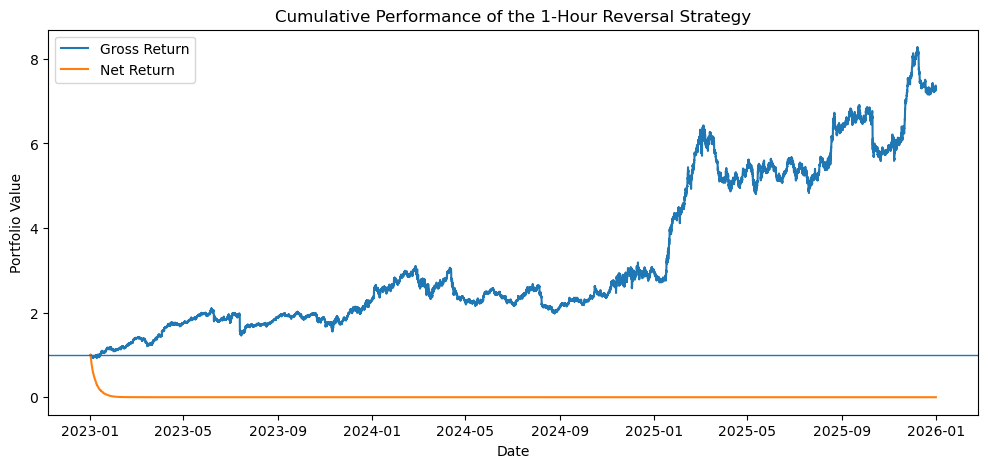

In [45]:

portfolio_1h["cumulative_gross_return"] = (
    1 + portfolio_1h["gross_return"]
).cumprod()

portfolio_1h["cumulative_net_return"] = (
    1 + portfolio_1h["net_return"]
).cumprod()

plt.figure(figsize=(12, 5))

plt.plot(
    portfolio_1h.index,
    portfolio_1h["cumulative_gross_return"],
    label="Gross Return",
)

plt.plot(
    portfolio_1h.index,
    portfolio_1h["cumulative_net_return"],
    label="Net Return",
)

plt.axhline(
    1,
    linewidth=1,
)

plt.title(
    "Cumulative Performance of the 1-Hour Reversal Strategy"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()

plt.show()

In [ ]:
# blue line: cumulative gross return before transaction costs
# orange line: cumulative net return after transaction costs

## Turnover and Transaction Costs

Hourly turnover is calculated as the sum of the absolute changes in portfolio weights across all cryptocurrencies.

A transaction-cost rate of 20 basis points is applied to the traded notional amount. Net portfolio returns are calculated by subtracting turnover-based transaction costs from gross returns.

This comparison shows whether the statistical reversal signal remains economically viable after realistic trading costs.

In [ ]:
# The 1-hour reversal signal generates positive gross returns before costs, but the hourly rebalancing frequency is so high that 
#transaction costs far exceed the gross profits. 
#After deducting costs, the strategy quickly loses all its capital.

# average gross return: 0.000089
# average turn over: 2.8208
# average transection: 0.00564
# average net return: -0.005553

## Baseline Strategy Performance Metrics

The following metrics evaluate the gross and net performance of the one-hour reversal strategy:

- annualised return;
- annualised volatility;
- Sharpe Ratio;
- maximum drawdown;
- average turnover;
- average transaction cost.

In [ ]:
# step 10:calculate annualised performance metrics

In [50]:


hours_per_year = 24 * 365

gross_mean = portfolio_1h["gross_return"].mean()
net_mean = portfolio_1h["net_return"].mean()

gross_volatility = portfolio_1h["gross_return"].std()
net_volatility = portfolio_1h["net_return"].std()

annualised_gross_return = gross_mean * hours_per_year
annualised_net_return = net_mean * hours_per_year

annualised_gross_volatility = (
    gross_volatility * np.sqrt(hours_per_year)
)

annualised_net_volatility = (
    net_volatility * np.sqrt(hours_per_year)
)

In [ ]:
# Annualised Mean Return=Hourly Mean Return×8760 ; Annualised Volatility=Hourly Volatility * squared
8760​


In [52]:
# Step 11: calculate annualised Sharpe Ratios

gross_sharpe = (
    gross_mean
    / gross_volatility
    * np.sqrt(hours_per_year)
)

net_sharpe = (
    net_mean
    / net_volatility
    * np.sqrt(hours_per_year)
)

print("Gross Sharpe Ratio:", gross_sharpe)
print("Net Sharpe Ratio:", net_sharpe)

Gross Sharpe Ratio: 1.6224192592268203
Net Sharpe Ratio: -96.78720326199533


In [ ]:
#
# Under the assumption of 0 transaction costs,  1.6224192592268203 show the strategy's average 
#return relative to its volatility is reasonably good.

# transection cost is very high

In [54]:
# Step 12: calculate Maximum Drawdown

def calculate_maximum_drawdown(returns):
    cumulative_value = (1 + returns).cumprod()
    running_peak = cumulative_value.cummax()
    drawdown = cumulative_value / running_peak - 1

    return drawdown.min()

In [56]:
gross_mdd = calculate_maximum_drawdown(
    portfolio_1h["gross_return"]
)

net_mdd = calculate_maximum_drawdown(
    portfolio_1h["net_return"]
)

print("Gross Maximum Drawdown:", gross_mdd)
print("Net Maximum Drawdown:", net_mdd)

Gross Maximum Drawdown: -0.3623462083351763
Net Maximum Drawdown: -1.0


In [ ]:
# Maximum Drawdown is big, big volativity, high risk
# loose all of them

In [58]:
# Step 13: create baseline performance summary

baseline_summary = pd.DataFrame(
    {
        "metric": [
            "Average Hourly Gross Return",
            "Average Hourly Net Return",
            "Annualised Gross Return",
            "Annualised Net Return",
            "Annualised Gross Volatility",
            "Annualised Net Volatility",
            "Gross Sharpe Ratio",
            "Net Sharpe Ratio",
            "Gross Maximum Drawdown",
            "Net Maximum Drawdown",
            "Average Turnover",
            "Average Transaction Cost",
        ],
        "value": [
            gross_mean,
            net_mean,
            annualised_gross_return,
            annualised_net_return,
            annualised_gross_volatility,
            annualised_net_volatility,
            gross_sharpe,
            net_sharpe,
            gross_mdd,
            net_mdd,
            portfolio_1h["turnover"].mean(),
            portfolio_1h["transaction_cost"].mean(),
        ],
    }
)

baseline_summary

,metric,value
0,Average Hourly Gross Return,0.000089
1,Average Hourly Net Return,-0.005553
2,Annualised Gross Return,0.776176
3,Annualised Net Return,-48.643786
4,Annualised Gross Volatility,0.478406
5,Annualised Net Volatility,0.502585
6,Gross Sharpe Ratio,1.622419
7,Net Sharpe Ratio,-96.787203
8,Gross Maximum Drawdown,-0.362346
9,Net Maximum Drawdown,-1.000000


In [ ]:
# step 14: storage my summary

In [60]:
backtest_results_dir = Path("results/backtesting")

backtest_results_dir.mkdir(
    parents=True,
    exist_ok=True,
)

baseline_summary.to_csv(
    backtest_results_dir
    / "baseline_1h_reversal_summary.csv",
    index=False,
)

print("Baseline performance summary saved.")

Baseline performance summary saved.


## Strategy Comparison 1: One-Hour Momentum

This strategy reverses the baseline portfolio direction. The top three cryptocurrencies are held long and the bottom three are held short, with hourly rebalancing.

In [ ]:
# step 1, build momemtum weight

In [63]:
df["momentum_weight_1h"] = 0.0

# Long the top three recent winners
df.loc[
    df["rank_1h"] >= 8,
    "momentum_weight_1h",
] = 1 / 3

# Short the bottom three recent losers
df.loc[
    df["rank_1h"] <= 3,
    "momentum_weight_1h",
] = -1 / 3

In [65]:
# step 2 : calculate the gross weight
df["momentum_weighted_return_1h"] = (
    df["momentum_weight_1h"]
    * df["future_return_1h"]
)

momentum_1h = (
    df.groupby("open_time")[
        "momentum_weighted_return_1h"
    ]
    .sum(min_count=1)
    .rename("gross_return")
    .to_frame()
    .dropna()
)

In [67]:
# step 3: calcluate the turnover
momentum_weights_wide = (
    df.pivot(
        index="open_time",
        columns="symbol",
        values="momentum_weight_1h",
    )
    .fillna(0)
    .sort_index()
)

momentum_turnover = (
    momentum_weights_wide
    .diff()
    .fillna(0)
    .abs()
    .sum(axis=1)
    .rename("turnover")
)

momentum_1h = momentum_1h.join(
    momentum_turnover,
    how="left",
)

In [69]:
# step 4: trasection cost
momentum_1h["transaction_cost"] = (
    momentum_1h["turnover"]
    * transaction_cost_rate
)

momentum_1h["net_return"] = (
    momentum_1h["gross_return"]
    - momentum_1h["transaction_cost"]
)

In [71]:
# step 5 : summary
momentum_summary = pd.Series(
    {
        "average_gross_return": (
            momentum_1h["gross_return"].mean()
        ),
        "average_turnover": (
            momentum_1h["turnover"].mean()
        ),
        "average_transaction_cost": (
            momentum_1h["transaction_cost"].mean()
        ),
        "average_net_return": (
            momentum_1h["net_return"].mean()
        ),
    }
)

momentum_summary

average_gross_return       -0.000089
average_turnover            2.820774
average_transaction_cost    0.005642
average_net_return         -0.005730
dtype: float64

In [ ]:
# momentum strategy's gross return is -0.000089

## Momentum Comparison

The one-hour momentum strategy produces a negative average gross return, while the reversal strategy produces an equal-sized positive gross return.

Both strategies have the same turnover and transaction costs because they use the same assets with opposite position directions.

This confirms that the short-term signal is more consistent with reversal than momentum. However, neither strategy is profitable after transaction costs.

In [ ]:
# The data shows a consistent reversal tendency across all test windows, but the reversal effect is mainly concentrated at shorter formation horizons, 
# while the predictive power at longer windows is very weak

## Strategy Comparison 2: 24-Hour Reversal with Daily Rebalancing

This strategy ranks cryptocurrencies using their previous 24-hour returns.

The bottom three cryptocurrencies are held long and the top three are held short. Portfolio weights are updated once per day at 00:00 UTC and held constant until the next daily rebalance.

The purpose is to test whether reducing the rebalancing frequency lowers turnover and improves net performance after transaction costs.

In [ ]:
# step 1: calculate the 24-hour signal and cross-sectional rank

In [77]:
df["signal_24h"] = (
    df.groupby("symbol")["close"]
    .pct_change(periods=24)
)

df["rank_24h"] = (
    df.groupby("open_time")["signal_24h"]
    .rank(
        method="first",
        ascending=True,
    )
)

In [79]:
# Step 2: identify daily rebalance times

In [81]:

df["is_daily_rebalance"] = (
    df["open_time"].dt.hour == 0
)

In [83]:
df[
    [
        "open_time",
        "symbol",
        "is_daily_rebalance",
    ]
].head(30)

,open_time,symbol,is_daily_rebalance
0,2023-01-01 00:00:00+00:00,ADAUSDT,True
1,2023-01-01 01:00:00+00:00,ADAUSDT,False
2,2023-01-01 02:00:00+00:00,ADAUSDT,False
3,2023-01-01 03:00:00+00:00,ADAUSDT,False
4,2023-01-01 04:00:00+00:00,ADAUSDT,False
5,2023-01-01 05:00:00+00:00,ADAUSDT,False
6,2023-01-01 06:00:00+00:00,ADAUSDT,False
7,2023-01-01 07:00:00+00:00,ADAUSDT,False
8,2023-01-01 08:00:00+00:00,ADAUSDT,False
9,2023-01-01 09:00:00+00:00,ADAUSDT,False


In [85]:
# Step 3: create target weights at daily rebalance times

df["daily_weight_24h"] = np.nan

In [87]:
df.loc[
    df["is_daily_rebalance"],
    "daily_weight_24h",
] = 0.0

In [93]:
# Long the bottom three cryptocurrencies

df.loc[
    df["is_daily_rebalance"]
    & (df["rank_24h"] <= 3),
    "daily_weight_24h",
] = 1 / 3

# Short the top three cryptocurrencies

df.loc[
    df["is_daily_rebalance"]
    & (df["rank_24h"] >= 8),
    "daily_weight_24h",
] = -1 / 3

In [95]:
# Step 4: hold daily weights until the next rebalance

df["daily_weight_24h"] = (
    df.groupby("symbol")["daily_weight_24h"]
    .ffill()
    .fillna(0)
)

In [97]:
# step 5: check
sample_date = pd.Timestamp(
    "2023-01-03",
    tz="UTC",
)

df.loc[
    (
        df["open_time"] >= sample_date
    )
    & (
        df["open_time"]
        < sample_date + pd.Timedelta(days=1)
    ),
    [
        "open_time",
        "symbol",
        "signal_24h",
        "rank_24h",
        "daily_weight_24h",
        "future_return_1h",
    ],
].head(30)

,open_time,symbol,signal_24h,rank_24h,daily_weight_24h,future_return_1h
48,2023-01-03 00:00:00+00:00,ADAUSDT,0.020900,5.0,0.000000,-0.003937
49,2023-01-03 01:00:00+00:00,ADAUSDT,0.021809,5.0,0.000000,-0.002767
50,2023-01-03 02:00:00+00:00,ADAUSDT,0.016519,5.0,0.000000,0.003567
51,2023-01-03 03:00:00+00:00,ADAUSDT,0.014017,5.0,0.000000,-0.001975
52,2023-01-03 04:00:00+00:00,ADAUSDT,0.012014,5.0,0.000000,0.004749
53,2023-01-03 05:00:00+00:00,ADAUSDT,0.016006,5.0,0.000000,-0.000788
54,2023-01-03 06:00:00+00:00,ADAUSDT,0.015612,5.0,0.000000,-0.001182
55,2023-01-03 07:00:00+00:00,ADAUSDT,-0.002755,1.0,0.000000,-0.003157
56,2023-01-03 08:00:00+00:00,ADAUSDT,-0.006685,2.0,0.000000,0.007522
57,2023-01-03 09:00:00+00:00,ADAUSDT,0.002758,6.0,0.000000,-0.002358


In [99]:
daily_sample_time = pd.Timestamp(
    "2023-01-03 00:00:00",
    tz="UTC",
)

df.loc[
    df["open_time"] == daily_sample_time,
    [
        "symbol",
        "signal_24h",
        "rank_24h",
        "daily_weight_24h",
    ],
].sort_values("rank_24h")

,symbol,signal_24h,rank_24h,daily_weight_24h
78957,BTCUSDT,0.006465,1.0,0.333333
52654,BNBUSDT,0.009442,2.0,0.333333
131563,ETHUSDT,0.014514,3.0,0.333333
157866,LINKUSDT,0.017303,4.0,0.000000
48,ADAUSDT,0.020900,5.0,0.000000
236775,XRPUSDT,0.027629,6.0,0.000000
105260,DOGEUSDT,0.027929,7.0,0.000000
26351,AVAXUSDT,0.033302,8.0,-0.333333
184169,LTCUSDT,0.066193,9.0,-0.333333
210472,SOLUSDT,0.140262,10.0,-0.333333


In [101]:
# step 6 check exposure

daily_exposure_check = (
    df.groupby("open_time")["daily_weight_24h"]
    .agg(
        net_exposure="sum",
        gross_exposure=lambda x: x.abs().sum(),
    )
)

daily_exposure_check.loc[
    daily_exposure_check["gross_exposure"] > 0
].head()


,net_exposure,gross_exposure
open_time,,
2023-01-02 00:00:00+00:00,0.0,2.0
2023-01-02 01:00:00+00:00,0.0,2.0
2023-01-02 02:00:00+00:00,0.0,2.0
2023-01-02 03:00:00+00:00,0.0,2.0
2023-01-02 04:00:00+00:00,0.0,2.0


In [103]:
# Step 7: calculate hourly gross portfolio returns

df["daily_weighted_return_24h"] = (
    df["daily_weight_24h"]
    * df["future_return_1h"]
)

daily_reversal_24h = (
    df.groupby("open_time")[
        "daily_weighted_return_24h"
    ]
    .sum(min_count=1)
    .rename("gross_return")
    .to_frame()
    .dropna()
)

daily_reversal_24h.head()

,gross_return
open_time,
2023-01-01 00:00:00+00:00,0.0
2023-01-01 01:00:00+00:00,0.0
2023-01-01 02:00:00+00:00,0.0
2023-01-01 03:00:00+00:00,0.0
2023-01-01 04:00:00+00:00,0.0


In [105]:
# Step 8: calculate turnover

daily_weights_wide = (
    df.pivot(
        index="open_time",
        columns="symbol",
        values="daily_weight_24h",
    )
    .fillna(0)
    .sort_index()
)

daily_turnover = (
    daily_weights_wide
    .diff()
    .fillna(0)
    .abs()
    .sum(axis=1)
    .rename("turnover")
)

daily_reversal_24h = (
    daily_reversal_24h
    .join(
        daily_turnover,
        how="left",
    )
)

daily_reversal_24h.head(30)

,gross_return,turnover
open_time,,
2023-01-01 00:00:00+00:00,0.000000e+00,0.0
2023-01-01 01:00:00+00:00,0.000000e+00,0.0
2023-01-01 02:00:00+00:00,0.000000e+00,0.0
2023-01-01 03:00:00+00:00,0.000000e+00,0.0
2023-01-01 04:00:00+00:00,0.000000e+00,0.0
2023-01-01 05:00:00+00:00,0.000000e+00,0.0
2023-01-01 06:00:00+00:00,0.000000e+00,0.0
2023-01-01 07:00:00+00:00,0.000000e+00,0.0
2023-01-01 08:00:00+00:00,0.000000e+00,0.0


In [107]:
# Step 9: apply transaction costs

daily_reversal_24h["transaction_cost"] = (
    daily_reversal_24h["turnover"]
    * transaction_cost_rate
)

daily_reversal_24h["net_return"] = (
    daily_reversal_24h["gross_return"]
    - daily_reversal_24h["transaction_cost"]
)

In [109]:
daily_reversal_summary = pd.Series(
    {
        "average_gross_return": (
            daily_reversal_24h[
                "gross_return"
            ].mean()
        ),
        "average_turnover": (
            daily_reversal_24h[
                "turnover"
            ].mean()
        ),
        "average_transaction_cost": (
            daily_reversal_24h[
                "transaction_cost"
            ].mean()
        ),
        "average_net_return": (
            daily_reversal_24h[
                "net_return"
            ].mean()
        ),
    }
)

daily_reversal_summary

average_gross_return       -0.000020
average_turnover            0.116366
average_transaction_cost    0.000233
average_net_return         -0.000253
dtype: float64

## Candidate Strategy 3: One-Hour Reversal with Rank Buffers

The baseline strategy rebalances whenever an asset moves in or out of the top or bottom three ranks. This can create excessive turnover when rankings change only slightly. work with sample in 2023-2024. 

The rank-buffer strategy uses stricter entry rules and wider exit rules:

- Enter a long position when an asset reaches rank 1 or 2.
- Keep an existing long position while its rank remains between 1 and 5.
- Enter a short position when an asset reaches rank 9 or 10.
- Keep an existing short position while its rank remains between 6 and 10.

The objective is to preserve the short-term reversal signal while reducing unnecessary trading caused by small ranking changes.

In [253]:
# Step 0: create the 2023–2024 development sample

development_df = df[
    df["open_time"] < "2025-01-01"
].copy()

development_df = (
    development_df
    .sort_values(["open_time", "symbol"])
    .reset_index(drop=True)
)

print(development_df["open_time"].min())
print(development_df["open_time"].max())
print(development_df.shape)

2023-01-01 00:00:00+00:00
2024-12-31 23:00:00+00:00
(175430, 30)


In [255]:
# step 1
development_df = (
    development_df
    .sort_values(["open_time", "symbol"])
    .copy()
)
rank_wide
future_returns_wide

symbol,ADAUSDT,AVAXUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LINKUSDT,LTCUSDT,SOLUSDT,XRPUSDT
open_time,,,,,,,,,,
2023-01-01 00:00:00+00:00,0.002863,0.000000,0.000407,0.001319,0.002006,0.001616,0.005791,0.002886,0.005005,0.000591
2023-01-01 01:00:00+00:00,0.001631,-0.000922,-0.002034,-0.000198,-0.001716,-0.000518,-0.001979,0.000432,-0.001992,-0.002067
2023-01-01 02:00:00+00:00,-0.000814,-0.001845,0.000000,-0.000916,0.000286,-0.001138,0.000901,-0.001150,-0.004990,0.000296
2023-01-01 03:00:00+00:00,-0.003260,-0.008318,-0.006115,-0.000677,-0.009307,-0.000938,-0.006304,-0.002447,-0.013039,-0.005915
2023-01-01 04:00:00+00:00,-0.000409,0.000932,0.001231,0.000536,0.002457,0.001358,0.003625,0.001732,-0.004065,0.001785
...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00+00:00,-0.000471,-0.003611,-0.001251,-0.006402,-0.004651,-0.002736,-0.004480,0.002528,0.001084,0.004063
2024-12-31 20:00:00+00:00,0.003887,0.001673,0.000413,0.003587,0.003378,0.001957,0.004000,0.007177,-0.004433,-0.001000
2024-12-31 21:00:00+00:00,-0.009386,-0.007793,-0.002462,-0.004375,-0.005475,-0.003839,-0.006972,-0.002215,-0.010509,-0.009246


In [257]:
# Step 2: define entry and exit rank thresholds

long_entry_max_rank = 2
long_exit_max_rank = 5

short_entry_min_rank = 9
short_exit_min_rank = 6
#Long: Enter at ranks 1–2; hold if already long while rank ≤ 5; exit at rank > 5.

#Short: Enter at ranks 9–10; hold if already short while rank ≥ 6; exit at rank < 6.



In [259]:
# Step 3: create the rank-buffer weight matrix

rank_buffer_weights = pd.DataFrame(
    0.0,
    index=rank_wide.index,
    columns=rank_wide.columns,
)
previous_positions = pd.Series(
    0.0,
    index=rank_wide.columns,
)

In [261]:
# Step 4: update positions using entry and exit buffers

for current_time in rank_wide.index:

    current_ranks = rank_wide.loc[current_time]

    current_positions = previous_positions.copy()

    for symbol in rank_wide.columns:

        current_rank = current_ranks[symbol]
        previous_position = previous_positions[symbol]

        if pd.isna(current_rank):
            current_positions[symbol] = 0.0
            continue

        # Existing long position
        if previous_position == 1.0:

            if current_rank <= long_exit_max_rank:
                current_positions[symbol] = 1.0
            else:
                current_positions[symbol] = 0.0

        # Existing short position
        elif previous_position == -1.0:

            if current_rank >= short_exit_min_rank:
                current_positions[symbol] = -1.0
            else:
                current_positions[symbol] = 0.0

        # No existing position
        else:

            if current_rank <= long_entry_max_rank:
                current_positions[symbol] = 1.0

            elif current_rank >= short_entry_min_rank:
                current_positions[symbol] = -1.0

            else:
                current_positions[symbol] = 0.0

    rank_buffer_weights.loc[current_time] = (
        current_positions
    )

    previous_positions = current_positions

In [262]:
# step 5: check original position
rank_buffer_position_counts = pd.DataFrame(
    {
        "number_of_longs": (
            rank_buffer_weights > 0
        ).sum(axis=1),

        "number_of_shorts": (
            rank_buffer_weights < 0
        ).sum(axis=1),
    }
)

rank_buffer_position_counts.describe()

,number_of_longs,number_of_shorts
count,17543.000000,17543.000000
mean,2.030325,2.073534
std,0.844475,0.806821
min,0.000000,0.000000
25%,1.000000,2.000000
50%,2.000000,2.000000
75%,3.000000,3.000000
max,5.000000,5.000000


In [263]:
# Step 6: normalize long and short weights separately

normalized_rank_buffer_weights = pd.DataFrame(
    0.0,
    index=rank_buffer_weights.index,
    columns=rank_buffer_weights.columns,
)

for current_time in rank_buffer_weights.index:

    positions = rank_buffer_weights.loc[current_time]

    long_assets = positions[
        positions > 0
    ].index

    short_assets = positions[
        positions < 0
    ].index

    if len(long_assets) > 0:
        normalized_rank_buffer_weights.loc[
            current_time,
            long_assets,
        ] = 1 / len(long_assets)

    if len(short_assets) > 0:
        normalized_rank_buffer_weights.loc[
            current_time,
            short_assets,
        ] = -1 / len(short_assets)

In [266]:
# step 7: check exposure
rank_buffer_exposure = pd.DataFrame(
    {
        "net_exposure": (
            normalized_rank_buffer_weights
            .sum(axis=1)
        ),
        "gross_exposure": (
            normalized_rank_buffer_weights
            .abs()
            .sum(axis=1)
        ),
    }
)

rank_buffer_exposure.head()

,net_exposure,gross_exposure
open_time,,
2023-01-01 00:00:00+00:00,0.0,0.0
2023-01-01 01:00:00+00:00,0.0,2.0
2023-01-01 02:00:00+00:00,0.0,2.0
2023-01-01 03:00:00+00:00,0.0,2.0
2023-01-01 04:00:00+00:00,0.0,2.0


In [267]:
# Step 8: calculate gross portfolio returns

rank_buffer_contributions = (
    normalized_rank_buffer_weights
    * future_returns_wide
)

rank_buffer_strategy = (
    rank_buffer_contributions
    .sum(axis=1, min_count=1)
    .rename("gross_return")
    .to_frame()
)

rank_buffer_strategy["gross_return"] = (
    rank_buffer_strategy["gross_return"]
    .fillna(0)
)

In [268]:
# Step 9: calculate turnover

rank_buffer_strategy["turnover"] = (
    normalized_rank_buffer_weights
    .diff()
    .fillna(0)
    .abs()
    .sum(axis=1)
)

In [269]:
# Step 10: apply transaction costs

transaction_cost_rate = 0.002

rank_buffer_strategy["transaction_cost"] = (
    rank_buffer_strategy["turnover"]
    * transaction_cost_rate
)

rank_buffer_strategy["net_return"] = (
    rank_buffer_strategy["gross_return"]
    - rank_buffer_strategy["transaction_cost"]
)

In [270]:
# step 11, summary
rank_buffer_summary = pd.Series(
    {
        "average_gross_return": (
            rank_buffer_strategy[
                "gross_return"
            ].mean()
        ),

        "average_turnover": (
            rank_buffer_strategy[
                "turnover"
            ].mean()
        ),

        "average_transaction_cost": (
            rank_buffer_strategy[
                "transaction_cost"
            ].mean()
        ),

        "average_net_return": (
            rank_buffer_strategy[
                "net_return"
            ].mean()
        ),
    }
)

rank_buffer_summary

average_gross_return        0.000084
average_turnover            2.437120
average_transaction_cost    0.004874
average_net_return         -0.004790
dtype: float64

In [271]:
# step 12 calcuate sharpe ratio and maximum mdd
hours_per_year = 24 * 365

rank_buffer_gross_mean = (
    rank_buffer_strategy["gross_return"].mean()
)

rank_buffer_net_mean = (
    rank_buffer_strategy["net_return"].mean()
)

rank_buffer_gross_vol = (
    rank_buffer_strategy["gross_return"].std()
)

rank_buffer_net_vol = (
    rank_buffer_strategy["net_return"].std()
)

rank_buffer_gross_sharpe = (
    rank_buffer_gross_mean
    / rank_buffer_gross_vol
    * np.sqrt(hours_per_year)
)

rank_buffer_net_sharpe = (
    rank_buffer_net_mean
    / rank_buffer_net_vol
    * np.sqrt(hours_per_year)
)

rank_buffer_gross_mdd = (
    calculate_maximum_drawdown(
        rank_buffer_strategy["gross_return"]
    )
)

rank_buffer_net_mdd = (
    calculate_maximum_drawdown(
        rank_buffer_strategy["net_return"]
    )
)

print(
    "Gross Sharpe Ratio:",
    rank_buffer_gross_sharpe,
)

print(
    "Net Sharpe Ratio:",
    rank_buffer_net_sharpe,
)

print(
    "Gross Maximum Drawdown:",
    rank_buffer_gross_mdd,
)

print(
    "Net Maximum Drawdown:",
    rank_buffer_net_mdd,
)

Gross Sharpe Ratio: 1.1362799033085291
Net Sharpe Ratio: -62.81381786752301
Gross Maximum Drawdown: -0.6260954964190308
Net Maximum Drawdown: -1.0


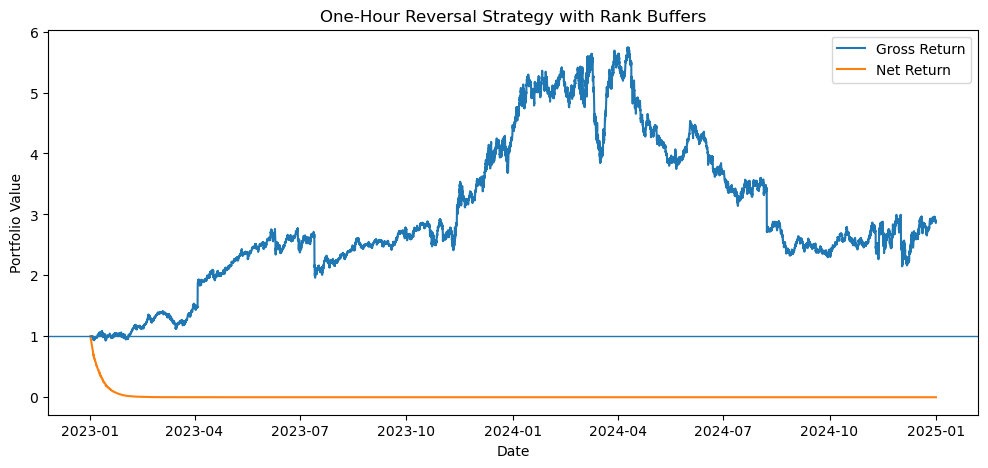

In [272]:
# plot 13: plot
rank_buffer_strategy[
    "cumulative_gross_return"
] = (
    1 + rank_buffer_strategy["gross_return"]
).cumprod()

rank_buffer_strategy[
    "cumulative_net_return"
] = (
    1 + rank_buffer_strategy["net_return"]
).cumprod()

plt.figure(figsize=(12, 5))

plt.plot(
    rank_buffer_strategy.index,
    rank_buffer_strategy[
        "cumulative_gross_return"
    ],
    label="Gross Return",
)

plt.plot(
    rank_buffer_strategy.index,
    rank_buffer_strategy[
        "cumulative_net_return"
    ],
    label="Net Return",
)

plt.axhline(
    1,
    linewidth=1,
)

plt.title(
    "One-Hour Reversal Strategy with Rank Buffers"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()

plt.show()

# ### conclusion

The rank-buffer strategy preserved most of the positive gross return of the baseline reversal strategy. However, average turnover remained high and transaction costs continued to dominate the signal return.

One reason is that long and short weights were renormalized whenever the number of positions changed. Therefore, even assets that remained in the portfolio experienced weight changes and generated additional turnover.

The current rank-buffer implementation reduced turnover only modestly and did not produce positive net performance under the assumed 20-basis-point execution cost.

## Strategy 4: Weekly Long-Only Momentum

This strategy tests whether medium-horizon momentum is more economically viable than short-term reversal.

Cryptocurrencies are ranked using their previous seven-day returns. At each weekly rebalancing date, the three highest-ranked assets are selected and held with equal weights.

The portfolio is long-only, fully invested and rebalanced once per week. The lower trading frequency is intended to substantially reduce turnover and transaction costs.

In [285]:
development_df

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,...,signal_24h,rank_24h,is_daily_rebalance,daily_weight_24h,daily_weighted_return_24h,signal_spread,trade_signal,conditional_weight_1h,conditional_weighted_return_1h,signal_168h
0,2023-01-01 00:00:00+00:00,0.24580,0.24590,0.24410,0.2445,4.476440e+06,1.096436e+06,1979,2.325058e+06,5.694572e+05,...,NaN,NaN,True,0.000000,0.000000,NaN,False,0.0,0.0,NaN
1,2023-01-01 00:00:00+00:00,10.90000,10.91000,10.82000,10.8500,2.738629e+04,2.973572e+05,767,9.162430e+03,9.949916e+04,...,NaN,NaN,True,0.000000,0.000000,NaN,False,0.0,0.0,NaN
2,2023-01-01 00:00:00+00:00,246.30000,246.70000,245.50000,245.7000,4.233967e+03,1.041745e+06,3402,1.853478e+03,4.559762e+05,...,NaN,NaN,True,0.000000,0.000000,NaN,False,0.0,0.0,NaN
3,2023-01-01 00:00:00+00:00,16541.77000,16545.70000,16508.39000,16529.6700,4.364836e+03,7.214629e+07,149854,2.179948e+03,3.603235e+07,...,NaN,NaN,True,0.000000,0.000000,NaN,False,0.0,0.0,NaN
4,2023-01-01 00:00:00+00:00,0.07024,0.07034,0.06941,0.0698,4.061193e+07,2.833808e+06,4852,1.916715e+07,1.336910e+06,...,NaN,NaN,True,0.000000,0.000000,NaN,False,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175425,2024-12-31 23:00:00+00:00,3339.88000,3345.98000,3328.47000,3337.7800,6.082788e+03,2.030623e+07,55808,3.443594e+03,1.149673e+07,...,-0.007157,5.0,False,0.000000,0.000000,0.013033,False,0.0,0.0,-0.044487
175426,2024-12-31 23:00:00+00:00,19.94000,20.08000,19.92000,20.0100,1.148785e+05,2.297818e+06,3781,4.923684e+04,9.846936e+05,...,-0.027697,1.0,False,0.333333,0.003665,0.013033,False,0.0,0.0,-0.212825
175427,2024-12-31 23:00:00+00:00,103.62000,103.84000,102.64000,103.2800,1.557654e+04,1.607255e+06,6332,5.543754e+03,5.723907e+05,...,0.039034,10.0,False,-0.333333,-0.005648,0.013033,False,0.0,0.0,-0.046793
175428,2024-12-31 23:00:00+00:00,191.14000,191.20000,189.20000,189.3100,1.358727e+05,2.582143e+07,49823,6.566047e+04,1.247432e+07,...,-0.010816,3.0,False,0.000000,0.000000,0.013033,False,0.0,0.0,-0.039474


In [287]:
# Step 1: calculate seven-day momentum signals

development_df["signal_168h"] = (
    development_df
    .groupby("symbol")["close"]
    .pct_change(periods=168)
)

In [289]:
development_df["rank_168h"] = (
    development_df
    .groupby("open_time")["signal_168h"]
    .rank(
        method="first",
        ascending=True,
    )
)

In [291]:
# Step 2: create wide ranking and return tables

rank_168h_wide = (
    development_df
    .pivot(
        index="open_time",
        columns="symbol",
        values="rank_168h",
    )
    .sort_index()
)

future_returns_wide = (
    development_df
    .pivot(
        index="open_time",
        columns="symbol",
        values="future_return_1h",
    )
    .sort_index()
)

In [293]:
# Step 3: identify weekly rebalancing times

weekly_rebalance_times = (
    rank_168h_wide.index[
        (rank_168h_wide.index.dayofweek == 0)
        & (rank_168h_wide.index.hour == 0)
    ]
)

print("Number of weekly rebalance dates:")
print(len(weekly_rebalance_times))

Number of weekly rebalance dates:
105


In [296]:
# Step 4: construct weekly long-only momentum weights

weekly_momentum_weights = pd.DataFrame(
    np.nan,
    index=rank_168h_wide.index,
    columns=rank_168h_wide.columns,
)

for current_time in weekly_rebalance_times:

    current_ranks = (
        rank_168h_wide
        .loc[current_time]
        .dropna()
    )

    # Require all ten cryptocurrencies
    if len(current_ranks) < 10:
        continue

    top_3_assets = (
        current_ranks
        .nlargest(3)
        .index
    )

    weekly_momentum_weights.loc[
        current_time,
        :
    ] = 0.0

    weekly_momentum_weights.loc[
        current_time,
        top_3_assets,
    ] = 1 / 3

In [298]:
# Step 5: hold weights until the next weekly rebalance

weekly_momentum_weights = (
    weekly_momentum_weights
    .ffill()
    .fillna(0.0)
)

In [300]:
# s
weekly_momentum_position_count = (
    weekly_momentum_weights > 0
).sum(axis=1)

weekly_momentum_position_count.describe()

count    17543.000000
mean         2.967166
std          0.312135
min          0.000000
25%          3.000000
50%          3.000000
75%          3.000000
max          3.000000
dtype: float64

In [302]:
# step 7
weekly_momentum_exposure = pd.DataFrame(
    {
        "net_exposure": (
            weekly_momentum_weights.sum(axis=1)
        ),
        "gross_exposure": (
            weekly_momentum_weights.abs().sum(axis=1)
        ),
    }
)

weekly_momentum_exposure.head(200)

,net_exposure,gross_exposure
open_time,,
2023-01-01 00:00:00+00:00,0.0,0.0
2023-01-01 01:00:00+00:00,0.0,0.0
2023-01-01 02:00:00+00:00,0.0,0.0
2023-01-01 03:00:00+00:00,0.0,0.0
2023-01-01 04:00:00+00:00,0.0,0.0
...,...,...
2023-01-09 03:00:00+00:00,1.0,1.0
2023-01-09 04:00:00+00:00,1.0,1.0
2023-01-09 05:00:00+00:00,1.0,1.0


In [304]:
# Step 8: calculate gross portfolio returns

weekly_momentum_contributions = (
    weekly_momentum_weights
    * future_returns_wide
)

weekly_momentum_strategy = (
    weekly_momentum_contributions
    .sum(axis=1, min_count=1)
    .rename("gross_return")
    .to_frame()
)

weekly_momentum_strategy["gross_return"] = (
    weekly_momentum_strategy[
        "gross_return"
    ].fillna(0)
)

In [306]:
# Step 9: calculate turnover

weekly_momentum_strategy["turnover"] = (
    weekly_momentum_weights
    .diff()
    .fillna(0)
    .abs()
    .sum(axis=1)
)

In [308]:
# Step 10: apply transaction costs

transaction_cost_rate = 0.002

weekly_momentum_strategy["transaction_cost"] = (
    weekly_momentum_strategy["turnover"]
    * transaction_cost_rate
)

weekly_momentum_strategy["net_return"] = (
    weekly_momentum_strategy["gross_return"]
    - weekly_momentum_strategy["transaction_cost"]
)

In [310]:
# step 11: result
weekly_momentum_summary = pd.Series(
    {
        "number_of_rebalances": (
            weekly_momentum_strategy[
                "turnover"
            ].gt(0).sum()
        ),

        "average_gross_return": (
            weekly_momentum_strategy[
                "gross_return"
            ].mean()
        ),

        "average_turnover": (
            weekly_momentum_strategy[
                "turnover"
            ].mean()
        ),

        "average_transaction_cost": (
            weekly_momentum_strategy[
                "transaction_cost"
            ].mean()
        ),

        "average_net_return": (
            weekly_momentum_strategy[
                "net_return"
            ].mean()
        ),
    }
)

weekly_momentum_summary

number_of_rebalances        104.000000
average_gross_return          0.000126
average_turnover              0.007885
average_transaction_cost      0.000016
average_net_return            0.000110
dtype: float64

In [315]:
from pathlib import Path

results_dir = Path(
    "/Users/nimo/crypto-statistical-arbitrage/results/model_development"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True,
)


In [319]:
# Calculate development-period final portfolio value

development_momentum_final_value = (
    1 + weekly_momentum_strategy["net_return"].fillna(0)
).cumprod().iloc[-1]

print("Development final portfolio value:")
print(development_momentum_final_value)

Development final portfolio value:
4.144756407395826


In [323]:
# Recalculate development-period performance metrics directly

HOURS_PER_YEAR = 24 * 365

development_net_return = (
    weekly_momentum_strategy["net_return"]
    .fillna(0)
)

development_net_mean = (
    development_net_return.mean()
)

development_net_vol = (
    development_net_return.std()
)

development_net_sharpe = (
    development_net_mean
    / development_net_vol
    * np.sqrt(HOURS_PER_YEAR)
)

In [325]:
def calculate_maximum_drawdown(
    returns: pd.Series,
) -> float:

    cumulative_value = (
        1 + returns.fillna(0)
    ).cumprod()

    running_maximum = (
        cumulative_value.cummax()
    )

    drawdown = (
        cumulative_value
        / running_maximum
        - 1
    )

    return drawdown.min()

In [327]:
development_net_mdd = (
    calculate_maximum_drawdown(
        development_net_return
    )
)

development_momentum_final_value = (
    1 + development_net_return
).cumprod().iloc[-1]

In [329]:
development_summary = pd.Series(
    {
        "average_hourly_net_return": (
            development_net_mean
        ),

        "hourly_net_volatility": (
            development_net_vol
        ),

        "annualized_net_sharpe_ratio": (
            development_net_sharpe
        ),

        "net_maximum_drawdown": (
            development_net_mdd
        ),

        "final_portfolio_value": (
            development_momentum_final_value
        ),

        "average_turnover": (
            weekly_momentum_strategy[
                "turnover"
            ].mean()
        ),

        "number_of_rebalances": (
            weekly_momentum_strategy[
                "turnover"
            ]
            .gt(0)
            .sum()
        ),
    },
    name="development_2023_2024",
)

development_summary

average_hourly_net_return        0.000110
hourly_net_volatility            0.007648
annualized_net_sharpe_ratio      1.350581
net_maximum_drawdown            -0.573262
final_portfolio_value            4.144756
average_turnover                 0.007885
number_of_rebalances           104.000000
Name: development_2023_2024, dtype: float64

In [331]:
development_summary_path = (
    results_dir
    / "weekly_momentum_development_summary.csv"
)

development_summary.to_csv(
    development_summary_path
)

print("Saved to:")
print(development_summary_path)

print(
    "File exists:",
    development_summary_path.exists(),
)

Saved to:
/Users/nimo/crypto-statistical-arbitrage/results/model_development/weekly_momentum_development_summary.csv
File exists: True
